# Antarctic Bottom Water budget in ECCOv4r4 (LLC90)

A **full water-mass budget for Antarctic Bottom Water (AABW)** south of 30°S, computed
with `xwmb` on the native, genuinely multi-tile ECCOv4r4 lat-lon-cap (LLC90) grid.

The AABW density class is defined by the **abyssal minimum of the $\sigma_2$ meridional
overturning streamfunction at 30°S**: the densest overturning cell exported northward
out of the Southern Ocean. We then decompose the budget for waters denser than that
threshold into its transformation terms following
[Drake et al. (2025)](https://doi.org/10.1029/2024MS004383):

$$\partial_t \mathcal{M}_{\geq} = \Psi_{\geq} + \mathcal{S}_{\geq}
   + \mathcal{G}^{(BF)}_{\geq} + \mathcal{G}^{(Mix)}_{\geq} + \mathcal{G}^{(Spu)}_{\geq},$$

where $\Psi_{\geq}$ is the convergent mass transport across the 30°S boundary (the
overturning streamfunction), $\mathcal{S}_{\geq}$ the surface mass source,
$\mathcal{G}^{(BF)}$/$\mathcal{G}^{(Mix)}$ the transformation by surface buoyancy fluxes
and interior mixing, and $\mathcal{G}^{(Spu)}$ the spurious numerical mixing (the residual).

This example exercises the topology-aware stack: the 13 LLC90 faces are stitched with
`face_connections`, the circumpolar 30°S boundary is traced across tile seams by
`regionate`/`sectionate`, and transports are integrated with the per-corner face index
`f_c`. The equation of state is ECCO's own **JMD95** (MITgcm), via `xeos`.

> **Data.** A curated ECCOv4r4 subset (2010) is downloaded from Zenodo
> ([10.5281/zenodo.21479854](https://doi.org/10.5281/zenodo.21479854)) on first run
> (~2.5 GB). Please cite the original NASA/ECCO sources listed in the Zenodo README.
> The `ECCOV4r4_native` budget preset requires a recent `xbudget`.

In [1]:
import warnings
warnings.simplefilter("ignore")

import numpy as np
import matplotlib.pyplot as plt

import xbudget
import xwmb

import load_example_ECCO_grid as ecco
print("xwmb", xwmb.__version__)

xwmb 0.6.0


## 1. Assemble the ECCO budget dataset

We merge the 2010 monthly-mean 3-D fluxes and surface forcing (annual-averaged), the
year-endpoint T/S/SSH snapshots (for the storage term), and the grid geometry, then add
the derived terms the `xbudget` ECCO preset expects (surface/geothermal heat tendencies,
the freshwater volume source, face mass transports `umo`/`vmo`, and snapshot $\sigma_2$).

In [2]:
ds = ecco.add_derived_budget_terms(ecco.assemble_ECCO_dataset(data_dir="../data/ecco"))
print("assembled:", len(ds.data_vars), "variables;  grid dims:", dict(ds.sizes))

assembled: 64 variables;  grid dims: {'tile': 13, 'j': 90, 'i': 90, 'j_g': 90, 'i_g': 90, 'k_p1': 51, 'k': 50, 'k_l': 50, 'time_bounds': 2, 'k_u': 50, 'nb': 4, 'nv': 2, 'time': 1}


## 2. Collect the heat / salt / mass budgets

`xbudget.collect_budgets` combines the raw ECCO diagnostics into the tendency terms of
each tracer budget, using the LLC90-topology-correct flux divergence across tile seams.
We pass `allow_rechunk=False` (the vertical flux differences on the multi-tile grid keep
consistent chunks this way).

In [3]:
budget_grid = ecco.construct_budget_grid(ds)
recipe = xbudget.load_preset_budget(model="ECCOV4r4_native")
xbudget.collect_budgets(budget_grid, recipe, allow_rechunk=False)
print("collected budget terms onto the grid dataset")

collected budget terms onto the grid dataset


## 3. Build the water-mass-budget grid and the region south of 30°S

The `xwmb` grid uses a `z_l`/`z_i` (center/interface) vertical coordinate so tracers can be
interpolated to interfaces and remapped conservatively into $\sigma_2$ space. The region
is the circumpolar cap south of 30°S; `regionate` traces its 30°S boundary across the LLC90
tile seams (a single loop with a per-corner face index `f_c`).

In [4]:
wmb_grid = ecco.construct_wmb_grid(budget_grid._ds)

southern_ocean = ds["geolat"] < -30.0

wmb = xwmb.WaterMassBudget(
    wmb_grid,
    recipe,
    region=southern_ocean,      # boolean mask -> MaskRegion (largest component)
    eos="jmd95",                # ECCO/MITgcm equation of state (via xeos)
    t_var="potential", s_var="practical",
    rho_ref=ecco.RHO0, cp=3994.0,
)
print("region boundary loops:", len(wmb.region.boundaries),
      "| multi-tile:", wmb.region.is_multitile)

region boundary loops: 1 | multi-tile: True


## 4. Compute the budget

`mass_budget("sigma2", greater_than=True, along_section=True)` evaluates every term as a
function of $\sigma_2$. `along_section=True` computes the convergent transport
$\Psi_{\geq}(\sigma_2)$ along the 30°S boundary with `sectionate` (the multi-tile path).

In [5]:
wmt = wmb.mass_budget(
    "sigma2", greater_than=True, along_section=True, default_bins=True,
    utr="umo", vtr="vmo",
).squeeze().load()

SV = ecco.RHO0 * 1e6           # kg/s per Sv (mass transport, rho_ref reference)
sigma2 = wmt["sigma2_l_target"]
print("budget terms:", [v for v in wmt.data_vars if not v.endswith(("_heat", "_salt"))])

budget terms: ['Eulerian_tendency', 'bottom_flux', 'diffusion', 'advection', 'surface_exchange_flux', 'kinematic_transformation', 'material_transformation', 'boundary_fluxes', 'mass_bounds', 'convergent_mass_transport', 'mass_source', 'layer_mass', 'mass_tendency', 'dt', 'realized_transformation', 'spurious_numerical_mixing', 'advection_plus_BC', 'diabatic_advection']


## 5. The $\sigma_2$ overturning streamfunction at 30°S, and the AABW class

$\Psi_{\geq}(\sigma_2)$ is the convergent mass transport across 30°S. Its **abyssal minimum**
(the densest, negative overturning cell) exports AABW northward and defines the AABW density
threshold $\sigma_2^\*$.

AABW sigma2* = 37.00 kg/m^3   (Psi* = -6.03 Sv)


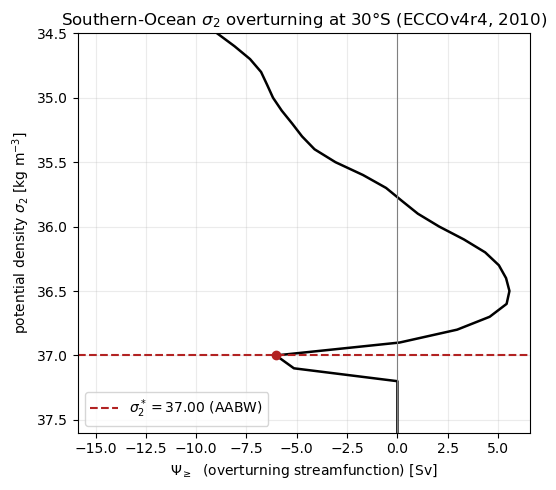

In [6]:
psi = wmt["convergent_mass_transport"] / SV     # Sv

# AABW class: abyssal minimum of the overturning streamfunction.
abyssal = psi.where(sigma2 > 36.8)
sigma2_star = float(abyssal.idxmin())
psi_star = float(abyssal.min())
print(f"AABW sigma2* = {sigma2_star:.2f} kg/m^3   (Psi* = {psi_star:.2f} Sv)")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(psi, sigma2, color="k", lw=1.8)
ax.axvline(0, color="grey", lw=0.8)
ax.axhline(sigma2_star, color="firebrick", ls="--",
           label=fr"$\sigma_2^* = {sigma2_star:.2f}$ (AABW)")
ax.plot(psi_star, sigma2_star, "o", color="firebrick")
ax.set_ylim(37.6, 34.5)
ax.set_xlabel(r"$\Psi_{\geq}$  (overturning streamfunction) [Sv]")
ax.set_ylabel(r"potential density $\sigma_2$ [kg m$^{-3}$]")
ax.set_title("Southern-Ocean $\sigma_2$ overturning at 30°S (ECCOv4r4, 2010)")
ax.legend(loc="lower left"); ax.grid(alpha=0.25)
plt.tight_layout()

## 6. The full AABW water-mass budget

Every transformation term as a function of $\sigma_2$. The dashed line marks the AABW
threshold $\sigma_2^\*$. The budget is closed by construction; the spurious numerical
mixing $\mathcal{G}^{(Spu)}$ is the residual not explained by the resolved material
transformation.

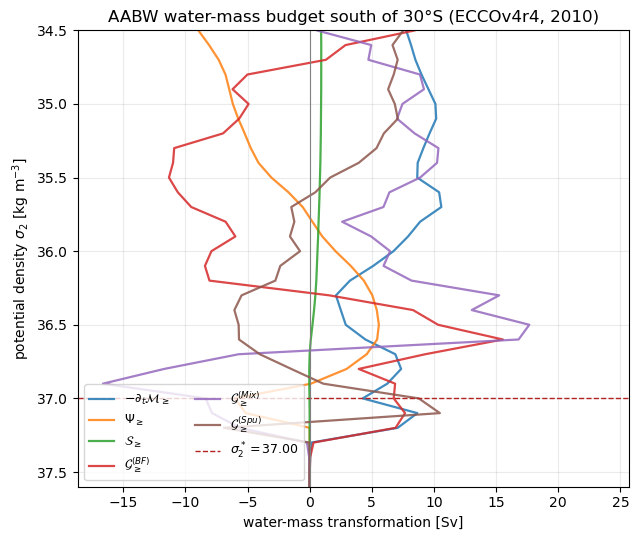

In [7]:
kw = dict(alpha=0.85, lw=1.6)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(-wmt["mass_tendency"]/SV,             sigma2, label=r"$-\partial_t\mathcal{M}_{\geq}$", **kw)
ax.plot( wmt["convergent_mass_transport"]/SV, sigma2, label=r"$\Psi_{\geq}$", **kw)
ax.plot( wmt["mass_source"]/SV,               sigma2, label=r"$\mathcal{S}_{\geq}$", **kw)
ax.plot( wmt["boundary_fluxes"]/SV,           sigma2, label=r"$\mathcal{G}^{(BF)}_{\geq}$", **kw)
ax.plot( wmt["diffusion"]/SV,                 sigma2, label=r"$\mathcal{G}^{(Mix)}_{\geq}$", **kw)
ax.plot( wmt["spurious_numerical_mixing"]/SV, sigma2, label=r"$\mathcal{G}^{(Spu)}_{\geq}$", **kw)
ax.axhline(sigma2_star, color="firebrick", ls="--", lw=1, label=fr"$\sigma_2^*={sigma2_star:.2f}$")
ax.axvline(0, color="grey", lw=0.8)
ax.set_ylim(37.6, 34.5)
ax.set_xlabel("water-mass transformation [Sv]")
ax.set_ylabel(r"potential density $\sigma_2$ [kg m$^{-3}$]")
ax.set_title("AABW water-mass budget south of 30°S (ECCOv4r4, 2010)")
ax.legend(loc="lower left", fontsize=9, ncol=2); ax.grid(alpha=0.25)
plt.tight_layout()

## Interpretation

At the AABW threshold $\sigma_2^\*$, the budget balances the northward export of dense
water across 30°S ($\Psi_{\geq}$) against its formation and destruction: surface buoyancy
forcing $\mathcal{G}^{(BF)}$ near Antarctica, interior mixing $\mathcal{G}^{(Mix)}$, the
(small) surface mass source $\mathcal{S}$, and the residual spurious numerical mixing
$\mathcal{G}^{(Spu)}$, with any imbalance stored as $\partial_t\mathcal{M}$ over 2010.

Because ECCO is a data-constrained state estimate (not a free-running model), its
$\mathcal{G}^{(Spu)}$ absorbs both genuine numerical mixing and the state-estimate
adjustments; it is diagnosed here purely as the budget residual.

Everything above ran on the native 13-tile grid: the 30°S boundary was traced across
tile seams, and both the transformations and the boundary transport broadcast/integrate
across tiles automatically.